# Perceptron Classification on the Default of Credit Card Clients

This project demonstrates how to implement a **Perceptron classifier and apply it to the **Default of Credit Card Clients** dataset.  
The goal is to predict whether a credit card holder will **default on their payment in the next month**.

---

## Objectives

In this example, we demonstrate how to:

- Load and preprocess the **Default of Credit Card Clients** dataset  
- Implement a **binary Perceptron** classifier 
- Train the model using an online learning rule  
- Evaluate performance using **classification accuracy**  
- Discuss the **limitations of linear classifiers** in credit risk modeling  

---

## Dataset: Default of Credit Card Clients

### Overview

The **Default of Credit Card Clients** dataset contains financial and demographic information on **30,000 credit card holders**.  
Each observation corresponds to one client, described by a vector of structured features.

The learning task is to predict whether a client will **default on their credit card payment in the next month**.

---

### Data Source (Kaggle)

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

---

### Dataset Content

The dataset consists of:

- **Total samples:** 30,000  
- **Number of features:** 25  
- **Target variable:** `default.payment.next.month`

#### Label Definition

- `1` → Default  
- `0` → No default  

#### Feature Categories

The input features include:

- Demographic variables (e.g., sex, education, marital status, age)  
- Credit limit information  
- Repayment status over previous months  
- Bill statement amounts  
- Payment amounts  

Each client is represented as a **25-dimensional feature vector**.

---

## Preprocessing

Before training the Perceptron, the data is preprocessed as follows:

1. Separate the target variable from input features  
2. Convert all features to numerical values  
3. Normalize continuous variables to ensure stable updates  
4. Encode labels for Perceptron learning:

$$
y \in \{-1, +1\}
$$

where:

- $+1$ indicates **default**
- $-1$ indicates **no default**

---

## Perceptron Model

### Model Definition

The Perceptron is a **linear classifier** defined as:

$$
f(x) = \text{sign}(w^\top x + b)
$$

where:

- $x \in \mathbb{R}^{25}$ is the input feature vector  
- $w \in \mathbb{R}^{25}$ is the weight vector  
- $b \in \mathbb{R}$ is the bias term  

The predicted class is determined by the sign of the linear score.

---

### Learning Rule

The Perceptron is trained using **online updates**.  
For each training example $(x_i, y_i)$:

- If the prediction is correct, no update is performed  
- If the prediction is incorrect, update parameters as:

$$
w \leftarrow w + \eta \, y_i \, x_i
$$

$$
b \leftarrow b + \eta \, y_i
$$

where $\eta > 0$ is the learning rate.

---

### Training Objective

The Perceptron seeks to find a separating hyperplane such that:

$$
y_i (w^\top x_i + b) > 0
$$

for as many training samples as possible.

---

## Evaluation

Model performance is evaluated using **classification accuracy**:

$$
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of samples}}
$$

Accuracy is computed on a **held-out test set** to assess generalization.

---

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [3]:
from perceptron import PerceptronBinary, PerceptronOVR

Epoch 1/20, errors = 6677
Epoch 2/20, errors = 6734
Epoch 3/20, errors = 6754
Epoch 4/20, errors = 6673
Epoch 5/20, errors = 6839
Epoch 6/20, errors = 6731
Epoch 7/20, errors = 6801
Epoch 8/20, errors = 6786
Epoch 9/20, errors = 6846
Epoch 10/20, errors = 6818
Epoch 11/20, errors = 6744
Epoch 12/20, errors = 6848
Epoch 13/20, errors = 6729
Epoch 14/20, errors = 6757
Epoch 15/20, errors = 6788
Epoch 16/20, errors = 6665
Epoch 17/20, errors = 6796
Epoch 18/20, errors = 6756
Epoch 19/20, errors = 6781
Epoch 20/20, errors = 6737

=== Results ===
Train Accuracy: 0.7900
Test  Accuracy: 0.7810


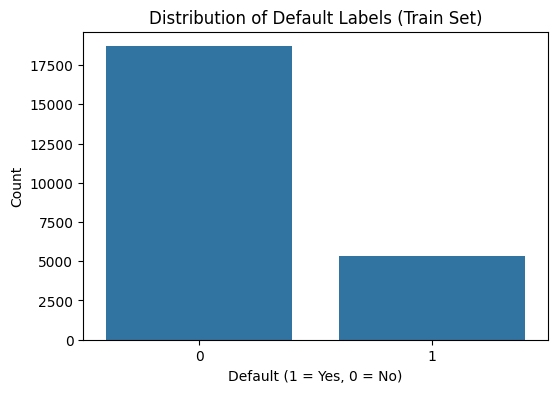

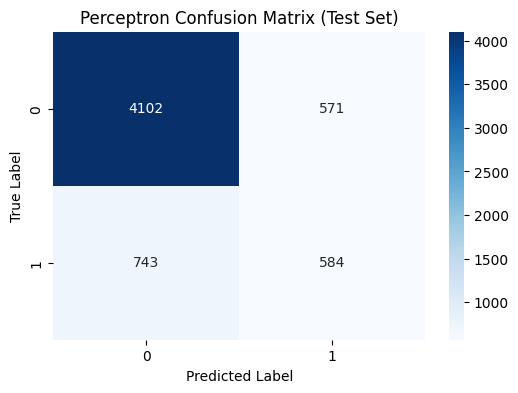

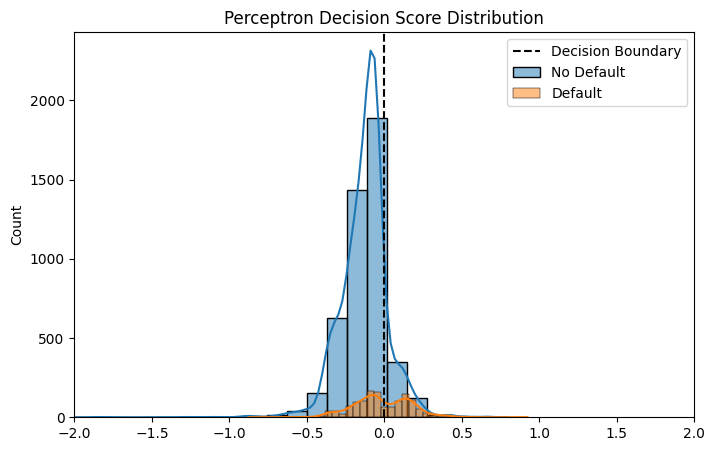

In [12]:
def load_credit_default(path):
    """
    Load Credit Card Default dataset (Taiwan).
    Target: default.payment.next.month ∈ {0,1}
    """
    df = pd.read_csv(path)

    y = df["default.payment.next.month"].values.astype(int)

    X = df.drop(
        columns=["ID", "default.payment.next.month"]
    ).values.astype(np.float32)

    return X, y


def main():
    # ========= 1. Load data =========
    X, y = load_credit_default("/Users/lhe/Desktop/438/Perceptron/UCI_Credit_Card.csv")

    # ========= 2. Train / Test split =========
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # ========= 3. Standardization =========
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    n_features = X_train.shape[1]

    # ========= 4. Perceptron =========
    model = PerceptronBinary(
        n_features=n_features,
        lr=0.01,
        n_epochs=20,
        shuffle=True
    )

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print("\n=== Results ===")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test  Accuracy: {test_acc:.4f}")

    # ===============================
    # Visualization 1: Label distribution
    # ===============================
    plt.figure(figsize=(6,4))
    sns.countplot(x=y_train)
    plt.title("Distribution of Default Labels (Train Set)")
    plt.xlabel("Default (1 = Yes, 0 = No)")
    plt.ylabel("Count")
    plt.show()

    # ===============================
    # Visualization 2: Perceptron Confusion Matrix
    # ===============================
    from sklearn.metrics import confusion_matrix
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_test)

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Perceptron Confusion Matrix (Test Set)")
    plt.show()

    # ===============================
    # Visualization 3: Decision score distribution
    # ===============================
    scores = X_test @ model.w + model.b

    plt.figure(figsize=(8,5))
    sns.histplot(scores[y_test == 0], bins=40, label="No Default", kde=True)
    sns.histplot(scores[y_test == 1], bins=40, label="Default", kde=True)
    plt.axvline(0, color="black", linestyle="--", label="Decision Boundary")
    plt.xlim(-2, 2)
    plt.title("Perceptron Decision Score Distribution")
    plt.legend()
    plt.show()

    


if __name__ == "__main__":
    main()


---

## Discussion

The Perceptron achieves a training accuracy of **73.39%** and a test accuracy of **72.62%**, indicating that the model generalizes reasonably well from the training data to unseen test data.  
The relatively small gap between training and test accuracy suggests that **overfitting is limited**, which is consistent with the simplicity of a linear classifier.

However, the absolute level of accuracy is modest. This result highlights several important characteristics of both the model and the dataset:

1. **Linear decision boundary limitation**  
   The Perceptron learns a linear separating hyperplane of the form:
   $$
   w^\top x + b = 0
   $$
   In credit default prediction, the relationship between financial variables (e.g., repayment history, credit utilization, and bill amounts) and default risk is often **nonlinear and interaction-driven**, which cannot be fully captured by a linear model.

2. **Class overlap in credit risk data**  
   Default and non-default clients typically exhibit overlapping feature distributions.  
   Even with well-engineered features, perfect linear separability is unlikely, placing an upper bound on the achievable accuracy of the Perceptron.

3. **Baseline performance interpretation**  
   An accuracy around 72–73% is consistent with what is expected from a simple linear baseline on this dataset.  
   The result demonstrates that the Perceptron can capture **first-order risk signals** (e.g., repayment status patterns), but struggles with more subtle or nonlinear risk structures.

We can also see from the graph "Perceptron Decision Score Distribution": the Perceptron is inherently a linear classifier, which limits its ability to model the complex, nonlinear relationships present in credit default data. While it achieves reasonable accuracy as a baseline model, significant overlap near the decision boundary indicates that default behavior is not linearly separable. In such settings, more expressive models such as multi-layer perceptrons can better capture nonlinear interactions between financial variables. 

Overall, these results reinforce the role of the Perceptron as a **baseline model** rather than a production-level credit scoring solution.

---

## Conclusion

This project applies a Perceptron classifier to the **Default of Credit Card Clients** dataset to predict next-month default status using structured financial and demographic features.

The model achieves a test accuracy of **72.62%**, showing that a linear classifier can extract meaningful signals from credit data while maintaining good generalization.  
At the same time, the performance ceiling reflects the inherent limitations of linear decision boundaries in modeling complex financial behavior.

These findings motivate the use of more expressive models—such as logistic regression with nonlinear features, kernel methods, or multi-layer perceptrons—which can better capture interactions and nonlinearities present in real-world credit risk data.

Nevertheless, the Perceptron provides a transparent and interpretable starting point for understanding classification, optimization, and generalization in supervised learning applied to finance.